# 01 Data Loading & EDA

Initial data inspection for the UCI student performance datasets (math and Portuguese tracks). Steps: load raw CSVs, inspect schema and missingness, create a simple pass/fail target, explore basic distributions, and save a cleaned copy for later modeling.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style="ticks")
raw_dir = Path("../../data/raw/uci")
processed_dir = Path("../../data/processed/performance")
mat_path = raw_dir / "student-mat.csv"
por_path = raw_dir / "student-por.csv"


In [2]:
# Load datasets
mat_df = pd.read_csv(mat_path, sep=";")
por_df = pd.read_csv(por_path, sep=";")

mat_shape, por_shape = mat_df.shape, por_df.shape
mat_shape, por_shape

((395, 33), (649, 33))

In [3]:
# Quick look at columns
print(f"Math columns ({len(mat_df.columns)}): {mat_df.columns.tolist()}")
print(f"Portuguese columns ({len(por_df.columns)}): {por_df.columns.tolist()}")

Math columns (33): ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']
Portuguese columns (33): ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [4]:
# Inspect dtypes and missing values
for name, df in [("Math", mat_df), ("Portuguese", por_df)]:
    print(f"\n{name} dataset info")
    print(df.info())
    missing = df.isnull().sum().sort_values(ascending=False)
    print("Top missing counts:")
    print(missing.head())



Math dataset info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    obj

In [5]:
# Basic statistics for numeric columns
mat_stats = mat_df.describe()
por_stats = por_df.describe()
mat_stats, por_stats

(              age        Medu        Fedu  traveltime   studytime    failures  \
 count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
 mean    16.696203    2.749367    2.521519    1.448101    2.035443    0.334177   
 std      1.276043    1.094735    1.088201    0.697505    0.839240    0.743651   
 min     15.000000    0.000000    0.000000    1.000000    1.000000    0.000000   
 25%     16.000000    2.000000    2.000000    1.000000    1.000000    0.000000   
 50%     17.000000    3.000000    2.000000    1.000000    2.000000    0.000000   
 75%     18.000000    4.000000    3.000000    2.000000    2.000000    0.000000   
 max     22.000000    4.000000    4.000000    4.000000    4.000000    3.000000   
 
            famrel    freetime       goout        Dalc        Walc      health  \
 count  395.000000  395.000000  395.000000  395.000000  395.000000  395.000000   
 mean     3.944304    3.235443    3.108861    1.481013    2.291139    3.554430   
 std      0.89

In [6]:
# Create pass/fail label based on final grade G3
mat_df["pass"] = (mat_df["G3"] >= 10).astype(int)
por_df["pass"] = (por_df["G3"] >= 10).astype(int)

pass_counts = mat_df["pass"].value_counts()
pass_counts

pass
1    265
0    130
Name: count, dtype: int64

In [7]:
# Drop duplicates, combine datasets, and save cleaned copies
mat_clean = mat_df.drop_duplicates().copy()
por_clean = por_df.drop_duplicates().copy()
mat_clean["dataset"] = "math"
por_clean["dataset"] = "portuguese"
combined_clean = pd.concat([mat_clean, por_clean], ignore_index=True)

processed_dir.mkdir(parents=True, exist_ok=True)
mat_clean.to_csv(processed_dir / "student_mat_cleaned.csv", index=False)
por_clean.to_csv(processed_dir / "student_por_cleaned.csv", index=False)
combined_clean.to_csv(processed_dir / "student_all_cleaned.csv", index=False)

(mat_clean.shape, por_clean.shape, combined_clean.shape)


((395, 35), (649, 35), (1044, 35))

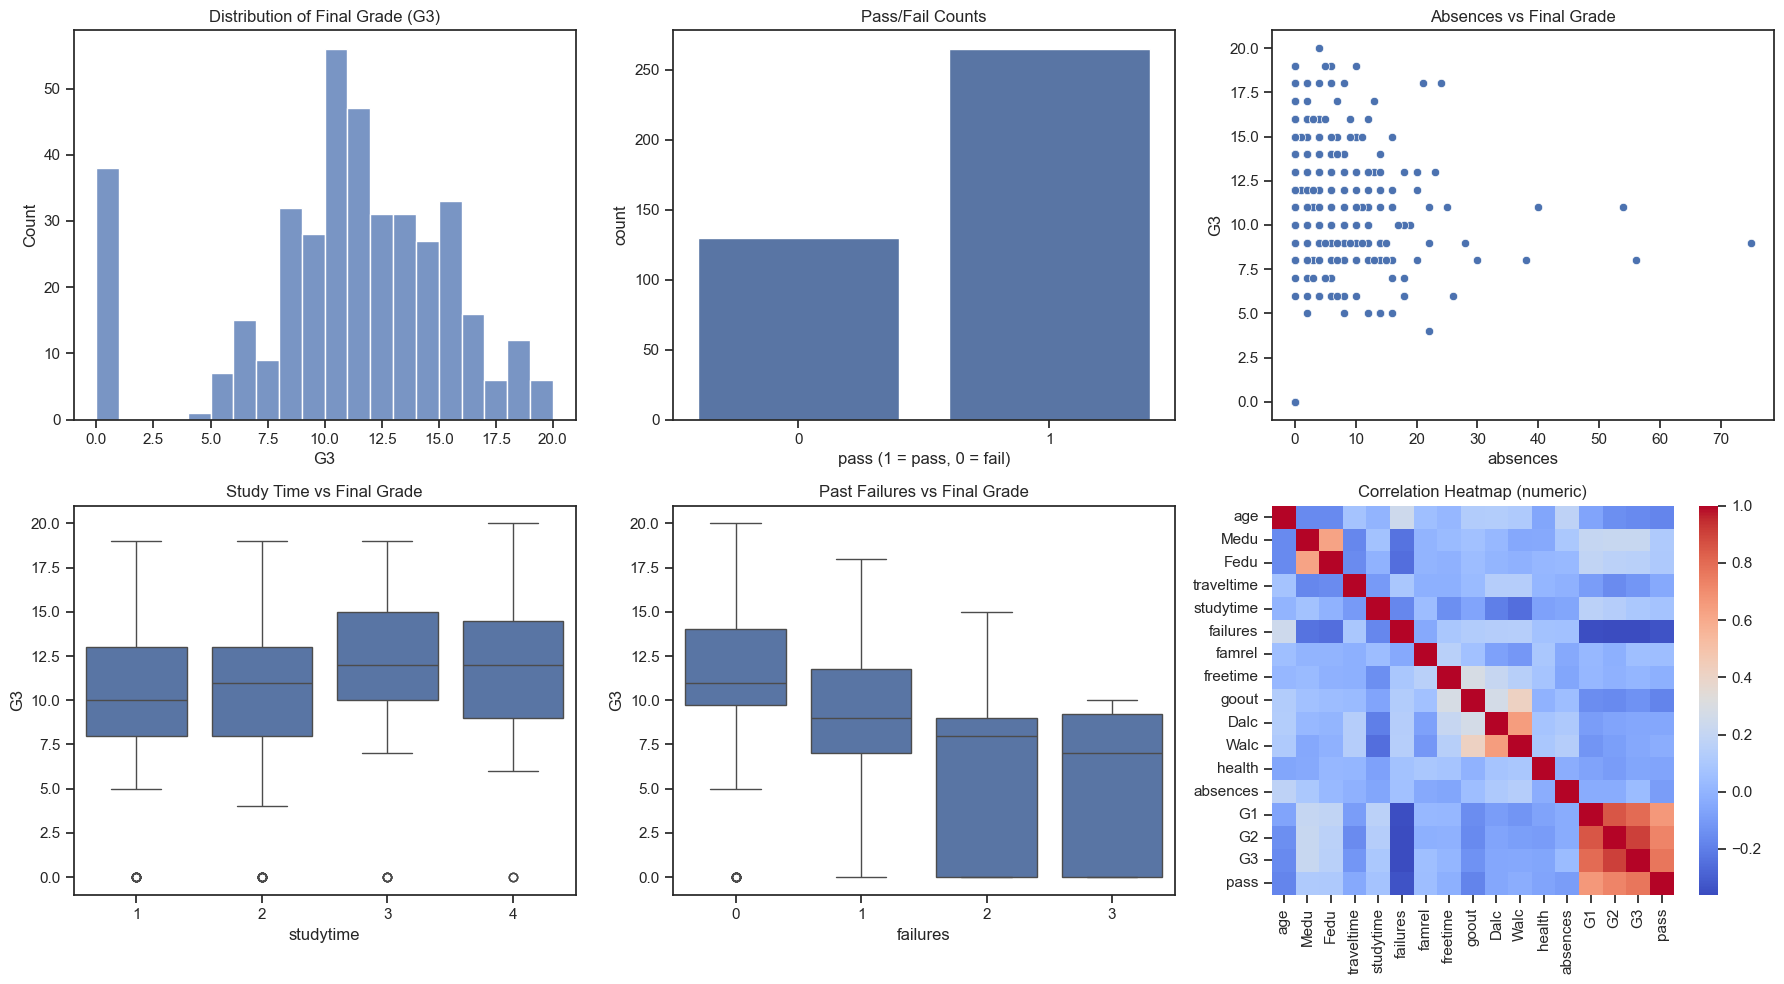

In [8]:
# EDA visualizations (Math dataset)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.histplot(mat_clean["G3"], bins=20, kde=False, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Final Grade (G3)")

sns.countplot(x="pass", data=mat_clean, ax=axes[0, 1])
axes[0, 1].set_title("Pass/Fail Counts")
axes[0, 1].set_xlabel("pass (1 = pass, 0 = fail)")

sns.scatterplot(x="absences", y="G3", data=mat_clean, ax=axes[0, 2])
axes[0, 2].set_title("Absences vs Final Grade")

sns.boxplot(x="studytime", y="G3", data=mat_clean, ax=axes[1, 0])
axes[1, 0].set_title("Study Time vs Final Grade")

sns.boxplot(x="failures", y="G3", data=mat_clean, ax=axes[1, 1])
axes[1, 1].set_title("Past Failures vs Final Grade")

corr = mat_clean.select_dtypes(include="number").corr()
sns.heatmap(corr, cmap="coolwarm", ax=axes[1, 2])
axes[1, 2].set_title("Correlation Heatmap (numeric)")

plt.tight_layout()
plt.show()


### Quick notes
- No missing values in either dataset based on initial check.
- `G1` and `G2` (first/second period grades) are expected to correlate strongly with `G3`.
- Absences and prior failures show negative association with `G3`; study time trends positive.
- Cleaned copies saved to `data/processed` for downstream work.
